# UAS Data Mining — IBM HR Analytics: Prediksi Attrition Karyawan

**Framework:** CRISP-DM (Cross-Industry Standard Process for Data Mining)

**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Sumber:** https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

**Anggota Kelompok:**
- Audi Pratiwi Naura — 24051214145
- Febby Aulia Diva Irdani — 24051214157


---
## Alur CRISP-DM yang digunakan:
1. Business Understanding
2. Data Understanding (EDA)
3. Data Preparation (Preprocessing)
4. Modeling — Model 1: XGBoost Classification
5. Modeling — Model 2: K-Means Clustering
6. Evaluation
7. Export Model

---
## TAHAP 0 — Install & Import Library

In [52]:
!pip install xgboost shap imbalanced-learn scikit-learn pandas matplotlib seaborn plotly joblib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# 🏢 UAS Data Mining — IBM HR Analytics: Prediksi Attrition Karyawan

**Framework:** CRISP-DM (Cross-Industry Standard Process for Data Mining)

**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Sumber:** https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

**Anggota Kelompok:**
- Audi Pratiwi Naura — 24051214145
- Febby Aulia Diva Irdani — 24051214157


---
## Alur CRISP-DM yang digunakan:
1. Business Understanding
2. Data Understanding (EDA)
3. Data Preparation (Preprocessing)
4. Modeling — Model 1: XGBoost Classification
5. Modeling — Model 2: K-Means Clustering
6. Evaluation
7. Export Model

In [53]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, accuracy_score
)

from imblearn.over_sampling import SMOTE

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import shap

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


---
## TAHAP 1 — Business Understanding

**Latar Belakang:**  
Attrition (pengunduran diri karyawan) adalah masalah besar bagi perusahaan karena biaya rekrutmen pengganti sangat mahal. IBM ingin mengidentifikasi karyawan mana yang berpotensi resign agar dapat dilakukan intervensi lebih awal.

**Business Objective:**
1. **Prediksi:** Apakah seorang karyawan akan resign? (Classification)
2. **Segmentasi:** Kelompok karyawan seperti apa yang paling berisiko? (Clustering)

**Success Criteria:**
- Akurasi model ≥ 80%
- ROC-AUC ≥ 0.75
- Silhouette Score clustering ≥ 0.30

---
## TAHAP 2 — Data Understanding (EDA)

### 2.1 Load Dataset

In [70]:
df = pd.read_csv('../dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f'Shape dataset: {df.shape}')
print(f'Jumlah baris  : {df.shape[0]}')
print(f'Jumlah kolom  : {df.shape[1]}')
df.head()

Shape dataset: (1470, 35)
Jumlah baris  : 1470
Jumlah kolom  : 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [ ]:
!pip install jinja2

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [69]:
# Statistik deskriptif
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
Age,1470.000000,36.923810,9.135373,18.000000,30.000000,36.000000,43.000000,60.000000
DailyRate,1470.000000,802.485714,403.509100,102.000000,465.000000,802.000000,1157.000000,1499.000000
DistanceFromHome,1470.000000,9.192517,8.106864,1.000000,2.000000,7.000000,14.000000,29.000000
Education,1470.000000,2.912925,1.024165,1.000000,2.000000,3.000000,4.000000,5.000000
EmployeeCount,1470.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
EmployeeNumber,1470.000000,1024.865306,602.024335,1.000000,491.250000,1020.500000,1555.750000,2068.000000
EnvironmentSatisfaction,1470.000000,2.721769,1.093082,1.000000,2.000000,3.000000,4.000000,4.000000
HourlyRate,1470.000000,65.891156,20.329428,30.000000,48.000000,66.000000,83.750000,100.000000
JobInvolvement,1470.000000,2.729932,0.711561,1.000000,2.000000,3.000000,3.000000,4.000000
JobLevel,1470.000000,2.063946,1.106940,1.000000,1.000000,2.000000,3.000000,5.000000


In [ ]:
# Cek missing values
missing = df.isnull().sum()
print('Missing values per kolom:')
print(missing[missing > 0] if missing.sum() > 0 else '✅ Tidak ada missing values!')

Missing values per kolom:
✅ Tidak ada missing values!


In [ ]:
import os
os.makedirs('../app/assets', exist_ok=True)

# Kode kamu yang sebelumnya
plt.savefig('../app/assets/dist_attrition.png', bbox_inches='tight')

<Figure size 768x576 with 0 Axes>

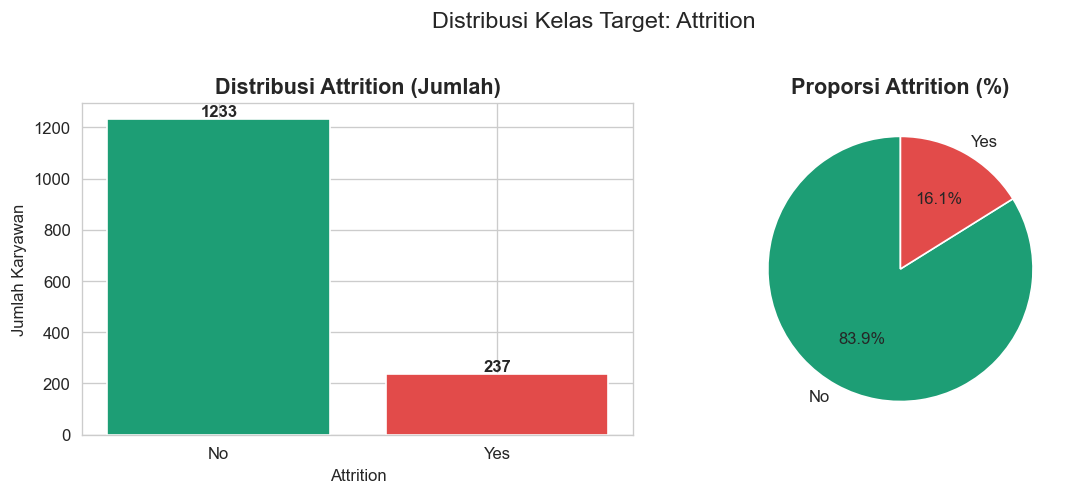


No  (Tidak resign) : 1233  (83.9%)
Yes (Resign)       : 237 (16.1%)

⚠️  Data tidak seimbang (imbalanced) — akan diatasi dengan SMOTE


In [ ]:
# Cek distribusi target (Attrition)
attrition_count = df['Attrition'].value_counts()
attrition_pct   = df['Attrition'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
colors = ['#1D9E75', '#E24B4A']
axes[0].bar(attrition_count.index, attrition_count.values, color=colors)
axes[0].set_title('Distribusi Attrition (Jumlah)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Jumlah Karyawan')
for i, v in enumerate(attrition_count.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(attrition_pct.values, labels=attrition_pct.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proporsi Attrition (%)', fontsize=13, fontweight='bold')

plt.suptitle('Distribusi Kelas Target: Attrition', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../app/assets/dist_attrition.png', bbox_inches='tight')
plt.show()

print(f'\nNo  (Tidak resign) : {attrition_count["No"]}  ({attrition_pct["No"]:.1f}%)')
print(f'Yes (Resign)       : {attrition_count["Yes"]} ({attrition_pct["Yes"]:.1f}%)')
print('\n⚠️  Data tidak seimbang (imbalanced) — akan diatasi dengan SMOTE')

### 2.2 Analisis Fitur Kategorikal

Fitur kategorikal: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


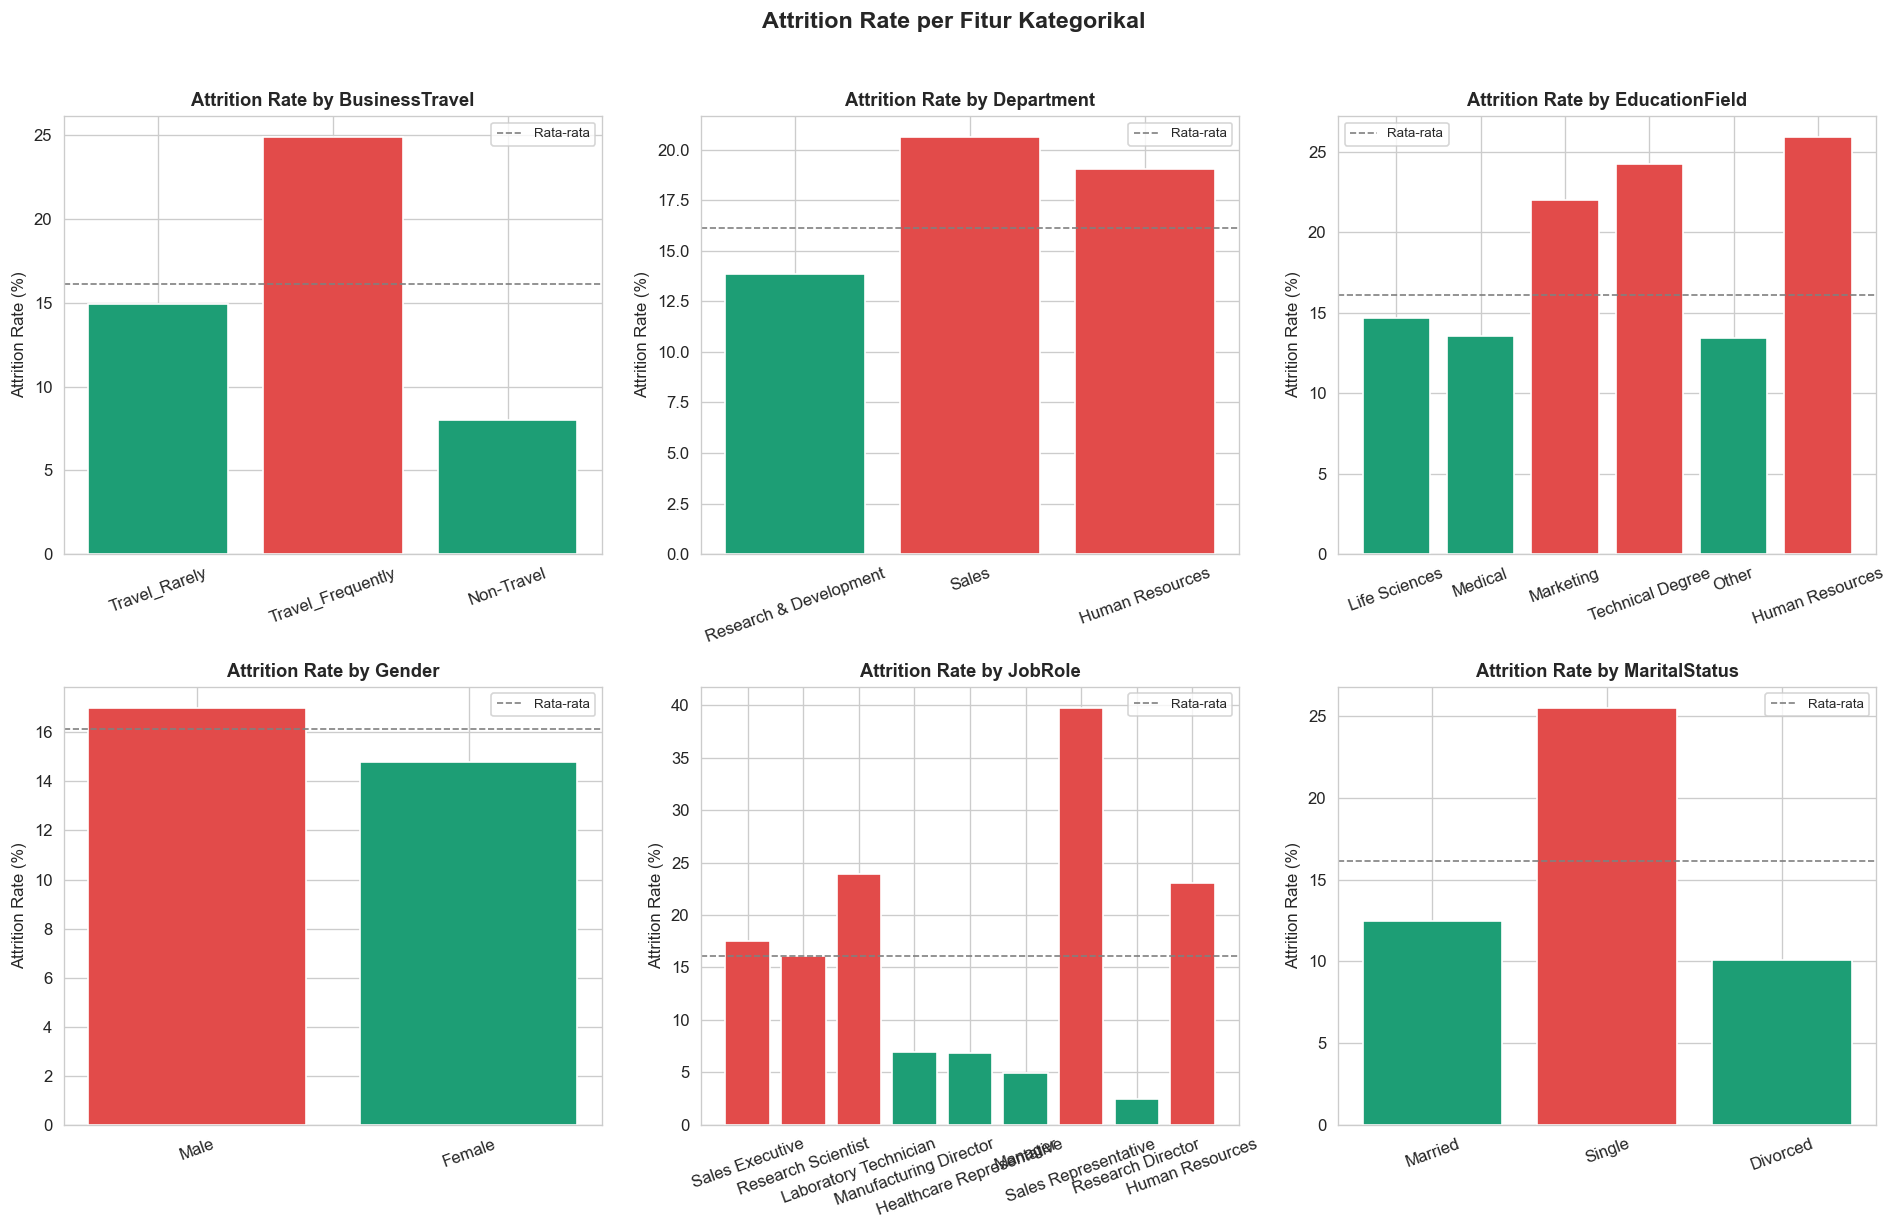

In [ ]:
# Fitur kategorikal
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Attrition')  # Target dipisah
print('Fitur kategorikal:', cat_cols)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:6]):
    order = df[col].value_counts().index
    temp = df.groupby(col)['Attrition'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reindex(order)
    
    bars = axes[i].bar(temp.index, temp.values,
                       color=['#E24B4A' if v > 15 else '#1D9E75' for v in temp.values])
    axes[i].set_title(f'Attrition Rate by {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].axhline(y=df['Attrition'].eq('Yes').mean()*100,
                    color='gray', linestyle='--', linewidth=1, label='Rata-rata')
    axes[i].legend(fontsize=8)

plt.suptitle('Attrition Rate per Fitur Kategorikal', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../app/assets/cat_attrition.png', bbox_inches='tight')
plt.show()

### 2.3 Analisis Fitur Numerik

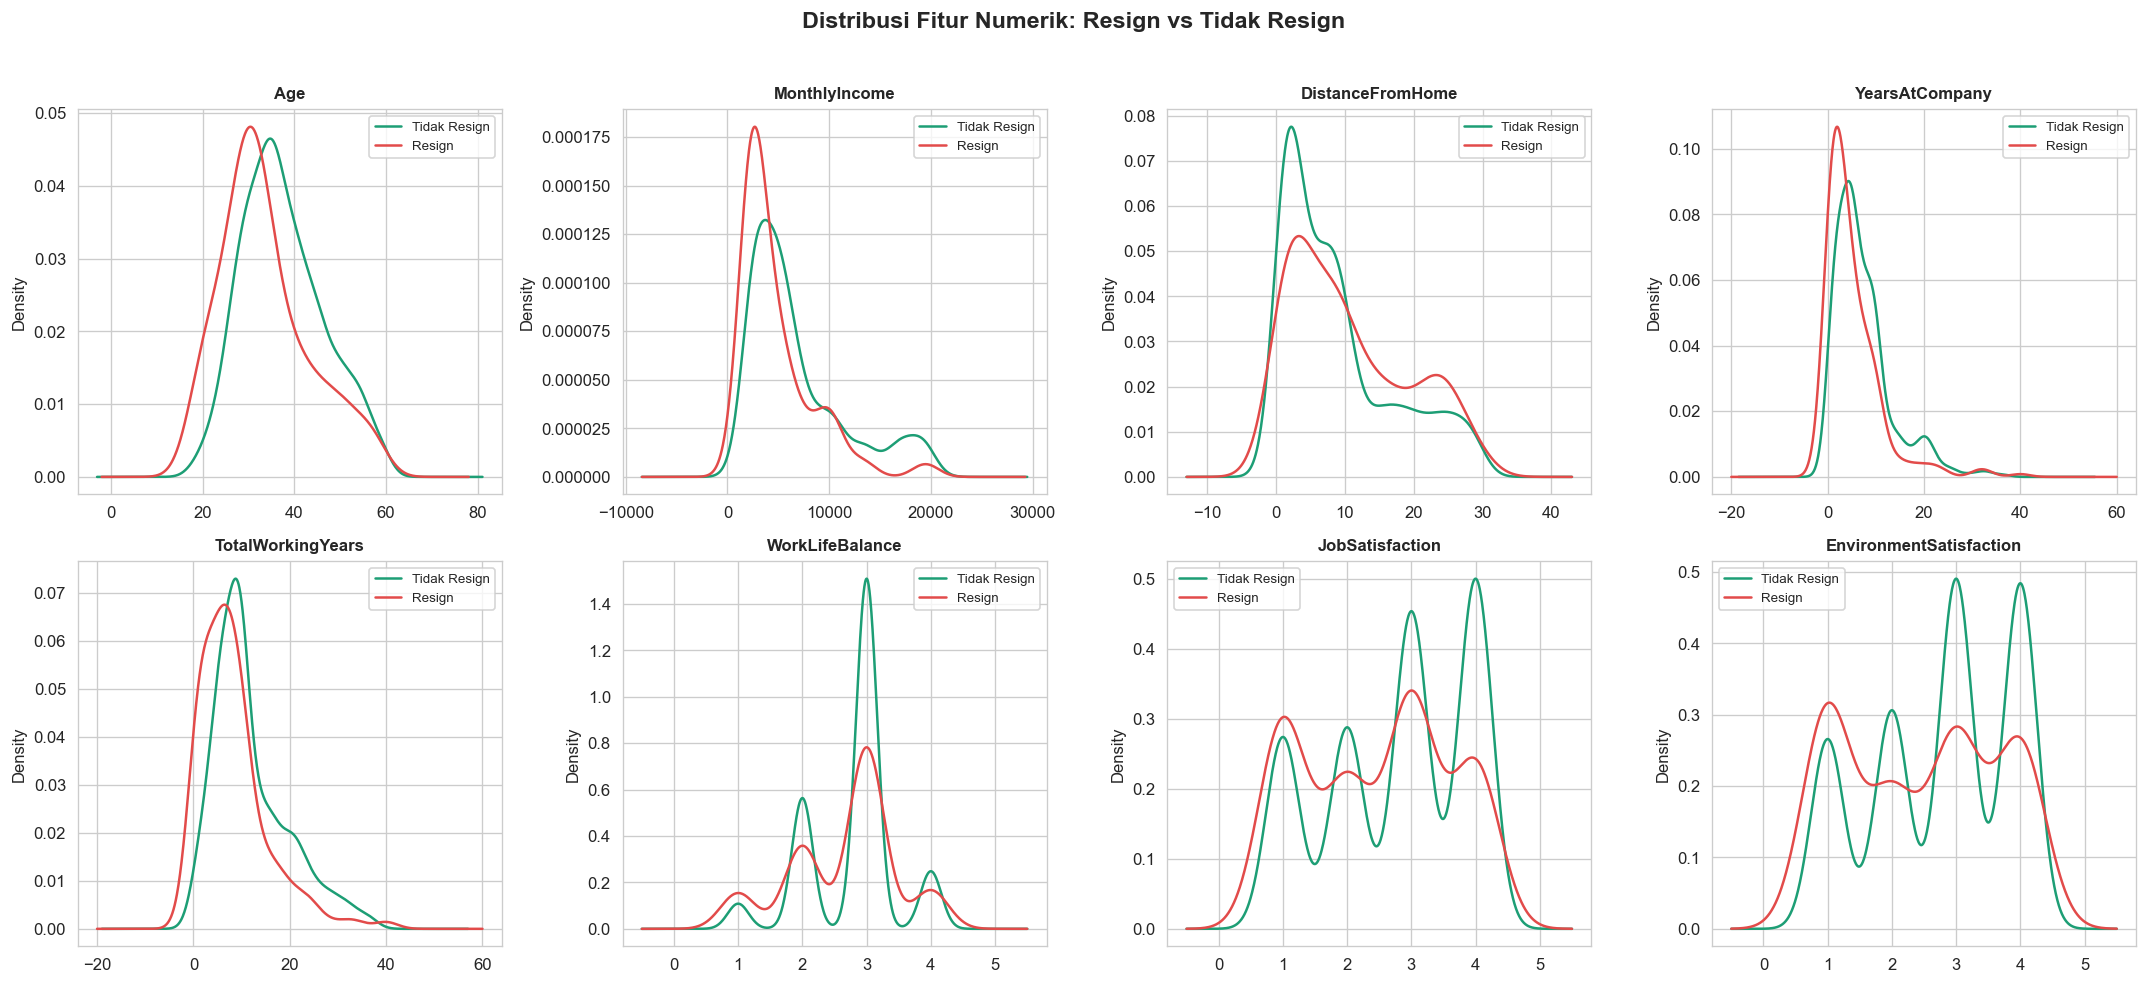

In [ ]:
# Fitur numerik penting
num_cols_key = ['Age', 'MonthlyIncome', 'DistanceFromHome',
                'YearsAtCompany', 'TotalWorkingYears', 'WorkLifeBalance',
                'JobSatisfaction', 'EnvironmentSatisfaction']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols_key):
    df[df['Attrition'] == 'No'][col].plot(kind='kde', ax=axes[i],
                                           label='Tidak Resign', color='#1D9E75')
    df[df['Attrition'] == 'Yes'][col].plot(kind='kde', ax=axes[i],
                                            label='Resign', color='#E24B4A')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Distribusi Fitur Numerik: Resign vs Tidak Resign',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../app/assets/num_dist.png', bbox_inches='tight')
plt.show()

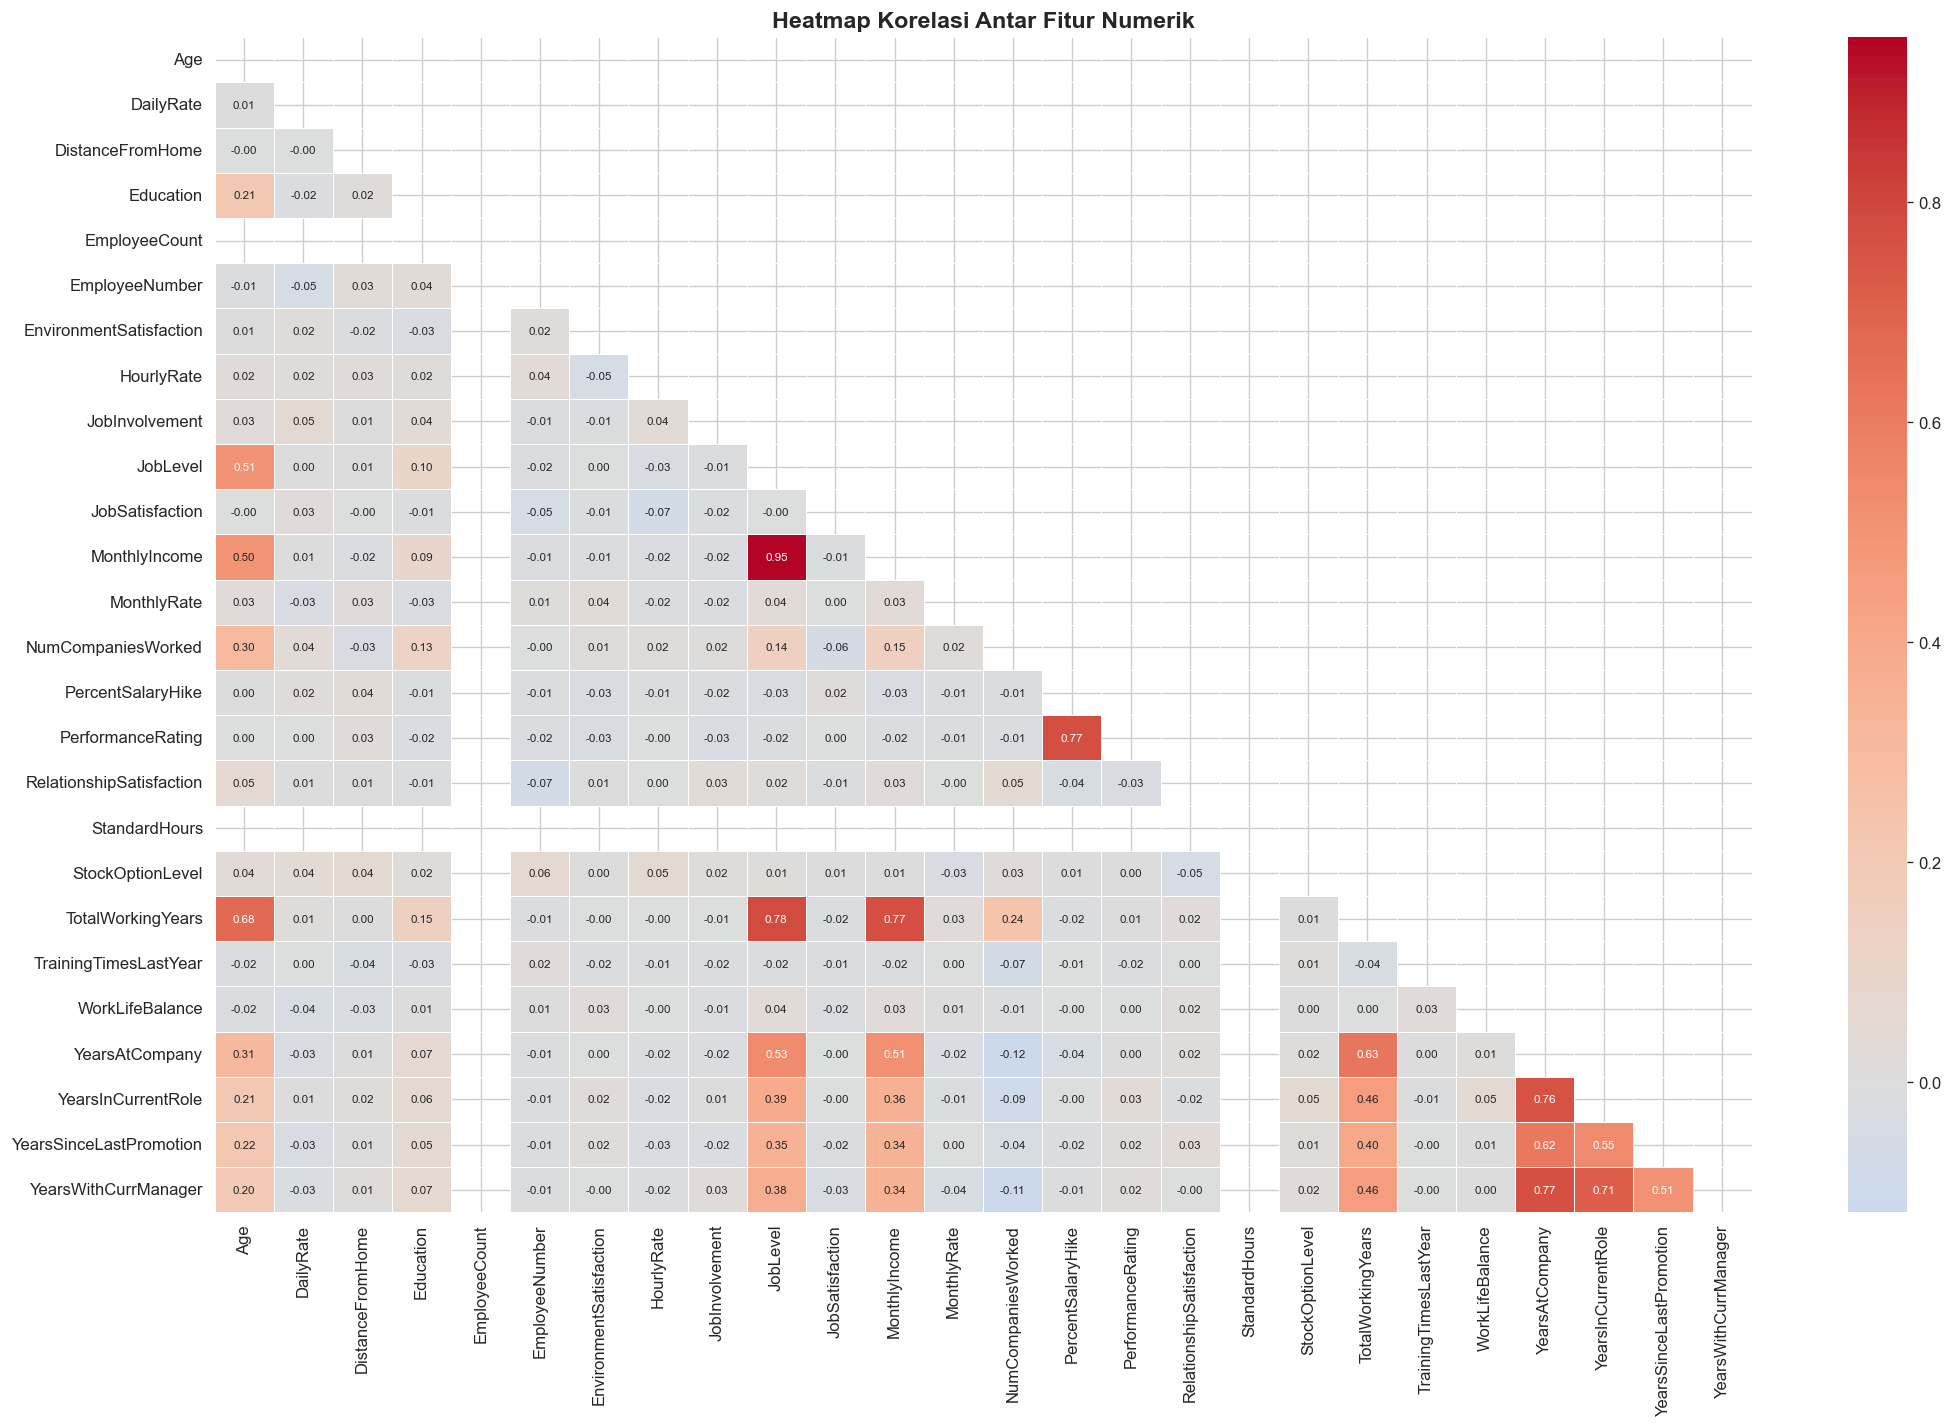

In [ ]:
# Heatmap korelasi
num_df = df.select_dtypes(include=np.number)
corr = num_df.corr()

plt.figure(figsize=(18, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 7})
plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../app/assets/heatmap_corr.png', bbox_inches='tight')
plt.show()

---
##  TAHAP 3 — Data Preparation (Preprocessing)

### 3.1 Hapus Fitur Tidak Relevan

In [ ]:
# Kolom dengan nilai konstan (tidak berguna untuk model)
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

df_clean = df.drop(columns=drop_cols)
print(f'Kolom dihapus     : {drop_cols}')
print(f'Shape setelah drop: {df_clean.shape}')

Kolom dihapus     : ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
Shape setelah drop: (1470, 31)


### 3.2 Encoding Fitur Kategorikal

In [ ]:
# Encode fitur kategorikal menggunakan LabelEncoder
df_encoded = df_clean.copy()
encoders = {}

cat_features = df_encoded.select_dtypes(include='object').columns.tolist()
print('Fitur yang akan di-encode:', cat_features)

for col in cat_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

# Simpan encoders untuk dipakai di Streamlit
joblib.dump(encoders, '../model/encoders.pkl')
print('\n✅ Encoding selesai!')
print('✅ Encoders tersimpan di model/encoders.pkl')
df_encoded.head(3)

Fitur yang akan di-encode: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

✅ Encoding selesai!
✅ Encoders tersimpan di model/encoders.pkl


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0


### 3.3 Feature Selection & Split Data

In [ ]:
# Pisahkan fitur (X) dan target (y)
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']  # 0 = No, 1 = Yes

print(f'Shape X (fitur) : {X.shape}')
print(f'Shape y (target): {y.shape}')
print(f'\nDistribusi target:')
print(y.value_counts())

# Simpan nama fitur untuk Streamlit
feature_names = X.columns.tolist()
joblib.dump(feature_names, '../model/feature_names.pkl')

Shape X (fitur) : (1470, 30)
Shape y (target): (1470,)

Distribusi target:
Attrition
0    1233
1     237
Name: count, dtype: int64


['../model/feature_names.pkl']

In [ ]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print('Distribusi SEBELUM SMOTE:', dict(y.value_counts()))
print('Distribusi SETELAH SMOTE :', dict(pd.Series(y_resampled).value_counts()))

Distribusi SEBELUM SMOTE: {0: np.int64(1233), 1: np.int64(237)}
Distribusi SETELAH SMOTE : {1: np.int64(1233), 0: np.int64(1233)}


In [ ]:
# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print(f'Data Training : {X_train.shape[0]} baris')
print(f'Data Testing  : {X_test.shape[0]} baris')

Data Training : 1972 baris
Data Testing  : 494 baris


---
## TAHAP 4 — Model 1: XGBoost Classification

**Tujuan:** Memprediksi apakah seorang karyawan akan resign (Attrition = Yes/No)

In [ ]:
# Inisialisasi dan training XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print('✅ Model XGBoost berhasil ditraining!')

✅ Model XGBoost berhasil ditraining!


### 4.1 Evaluasi Model Classification

In [ ]:
# Prediksi
y_pred       = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Metrik evaluasi
acc     = accuracy_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print('=' * 45)
print('     HASIL EVALUASI MODEL XGBOOST')
print('=' * 45)
print(f'  Accuracy    : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  F1-Score    : {f1:.4f}')
print(f'  ROC-AUC     : {roc_auc:.4f}')
print('=' * 45)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Tidak Resign', 'Resign']))

     HASIL EVALUASI MODEL XGBOOST
  Accuracy    : 0.9231  (92.31%)
  F1-Score    : 0.9234
  ROC-AUC     : 0.9738

Classification Report:
              precision    recall  f1-score   support

Tidak Resign       0.93      0.92      0.92       247
      Resign       0.92      0.93      0.92       247

    accuracy                           0.92       494
   macro avg       0.92      0.92      0.92       494
weighted avg       0.92      0.92      0.92       494



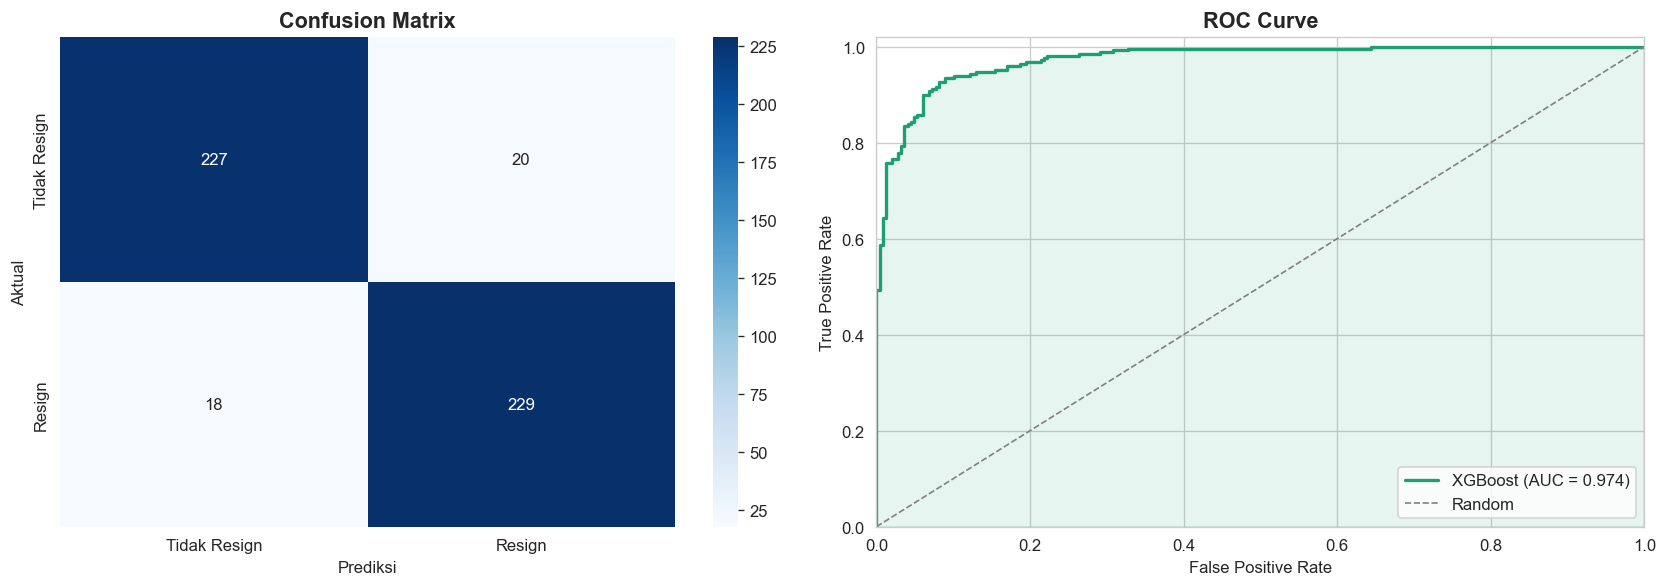

In [ ]:
# Visualisasi: Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Resign', 'Resign'],
            yticklabels=['Tidak Resign', 'Resign'], ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#1D9E75', lw=2,
             label=f'XGBoost (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#1D9E75')

plt.tight_layout()
plt.savefig('../app/assets/model1_eval.png', bbox_inches='tight')
plt.show()

### 4.2 Explainable AI dengan SHAP 

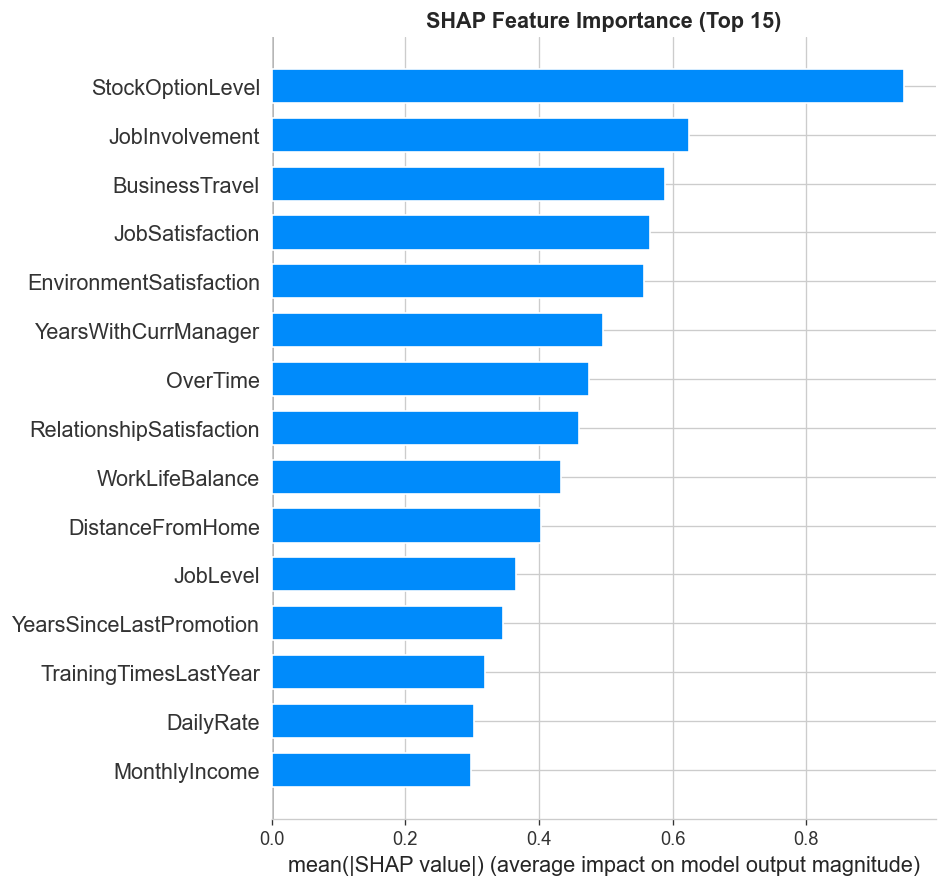

In [ ]:
# SHAP Explainer
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary Plot — Feature Importance Global
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_names,
                  plot_type='bar',
                  max_display=15,
                  show=False)
plt.title('SHAP Feature Importance (Top 15)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../app/assets/shap_bar.png', bbox_inches='tight')
plt.show()

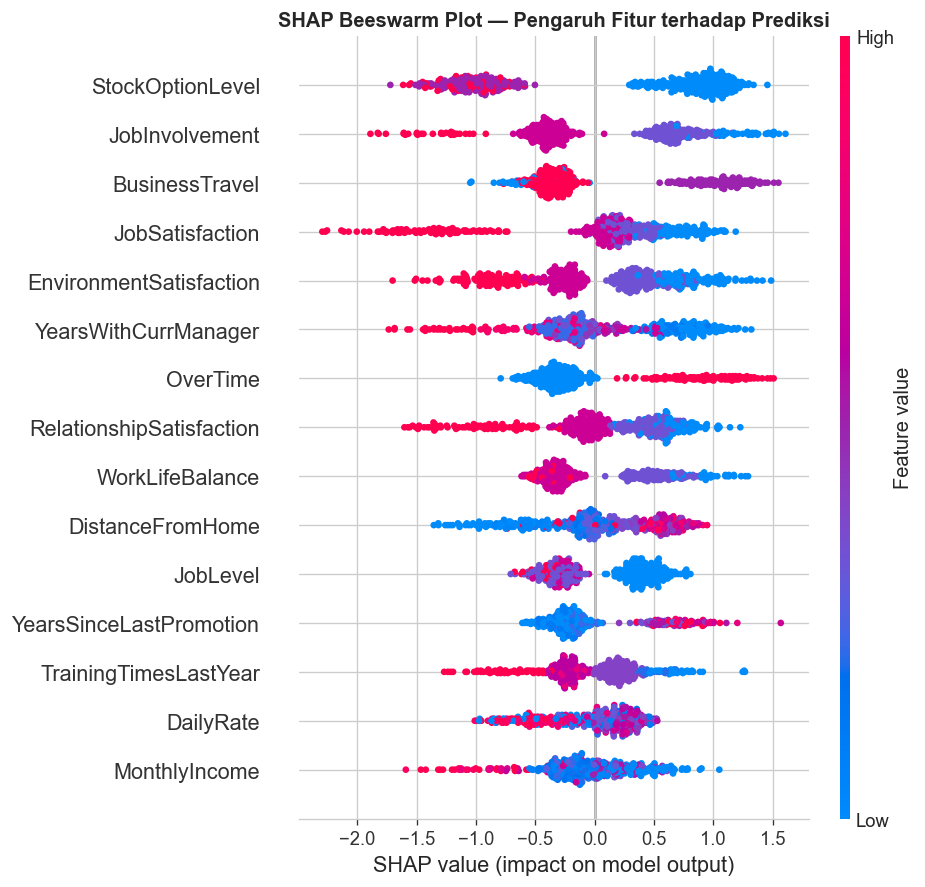


📌 Interpretasi:
  - Merah  = nilai fitur tinggi
  - Biru   = nilai fitur rendah
  - Kanan  = meningkatkan probabilitas Resign
  - Kiri   = menurunkan probabilitas Resign


In [ ]:
# SHAP Beeswarm Plot — Distribusi pengaruh setiap fitur
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_names,
                  max_display=15,
                  show=False)
plt.title('SHAP Beeswarm Plot — Pengaruh Fitur terhadap Prediksi', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../app/assets/shap_beeswarm.png', bbox_inches='tight')
plt.show()

print('\n📌 Interpretasi:')
print('  - Merah  = nilai fitur tinggi')
print('  - Biru   = nilai fitur rendah')
print('  - Kanan  = meningkatkan probabilitas Resign')
print('  - Kiri   = menurunkan probabilitas Resign')

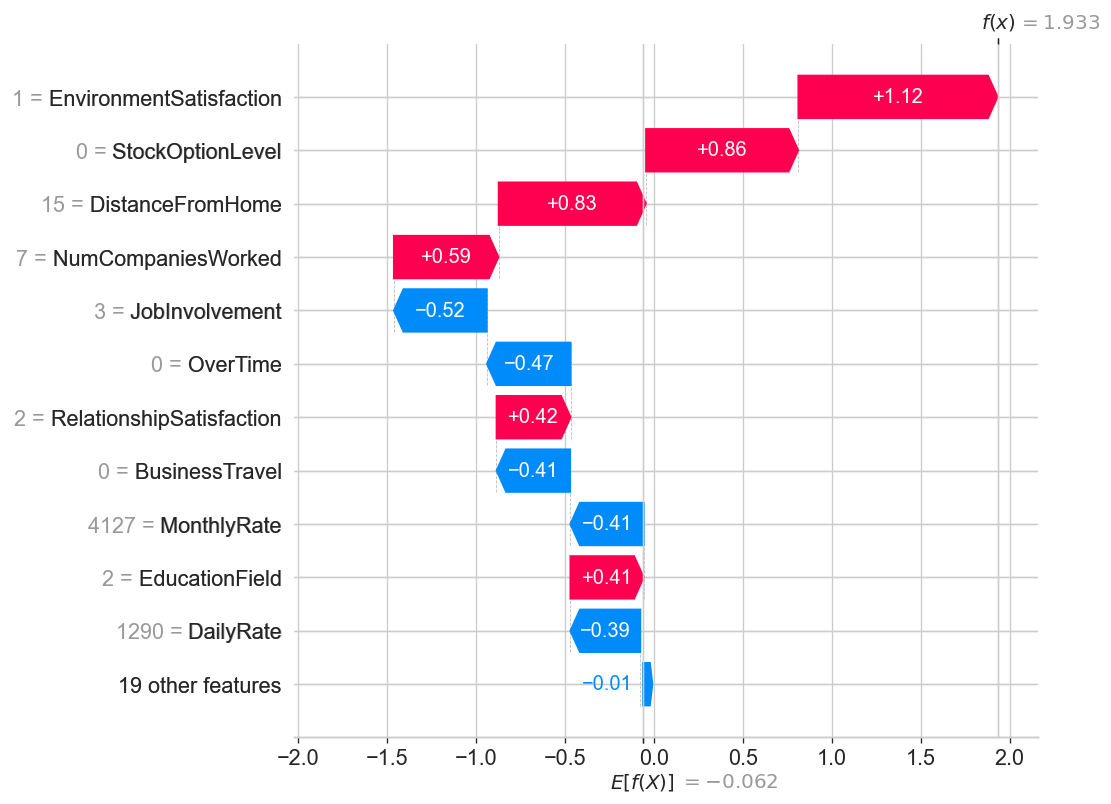

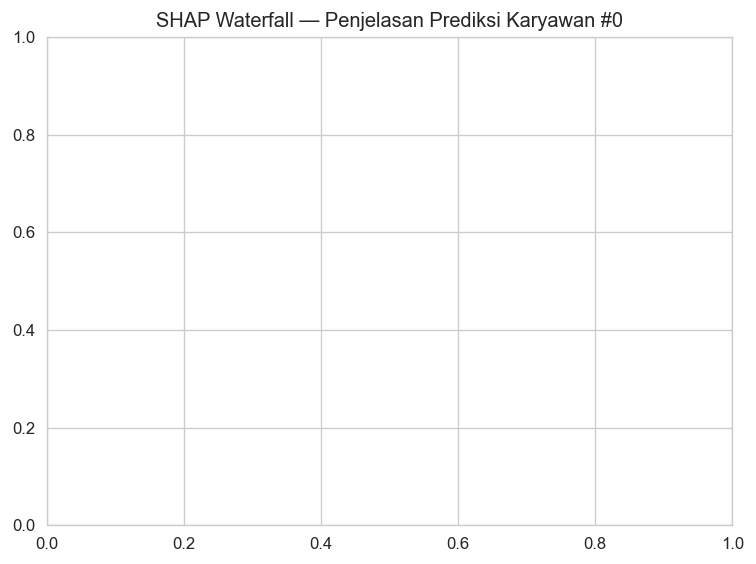

In [ ]:
resign_idx = np.where(y_pred == 1)[0][0]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[resign_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[resign_idx],
        feature_names=feature_names
    ),
    max_display=12
)
plt.title(f'SHAP Waterfall — Penjelasan Prediksi Karyawan #{resign_idx}', fontsize=12)
plt.tight_layout()
plt.savefig('../app/assets/shap_waterfall.png', bbox_inches='tight')
plt.show()

In [ ]:
# Simpan model XGBoost
joblib.dump(xgb_model, '../model/xgb_model.pkl')
joblib.dump(explainer, '../model/shap_explainer.pkl')
print('✅ Model XGBoost tersimpan di model/xgb_model.pkl')
print('✅ SHAP explainer tersimpan di model/shap_explainer.pkl')

✅ Model XGBoost tersimpan di model/xgb_model.pkl
✅ SHAP explainer tersimpan di model/shap_explainer.pkl


---
## TAHAP 5 — Model 2: K-Means Clustering

**Tujuan:** Mengelompokkan karyawan ke dalam segmen berdasarkan profil risiko

In [ ]:
# Pilih fitur relevan untuk clustering
cluster_features = [
    'Age', 'MonthlyIncome', 'JobSatisfaction',
    'WorkLifeBalance', 'EnvironmentSatisfaction',
    'YearsAtCompany', 'DistanceFromHome',
    'OverTime', 'JobInvolvement', 'PerformanceRating'
]

X_cluster = df_encoded[cluster_features].copy()

# Normalisasi data (penting untuk K-Means)
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)

joblib.dump(scaler, '../model/scaler.pkl')
joblib.dump(cluster_features, '../model/cluster_features.pkl')
print(f'✅ Fitur clustering: {cluster_features}')
print(f'✅ Shape data clustering: {X_scaled.shape}')

✅ Fitur clustering: ['Age', 'MonthlyIncome', 'JobSatisfaction', 'WorkLifeBalance', 'EnvironmentSatisfaction', 'YearsAtCompany', 'DistanceFromHome', 'OverTime', 'JobInvolvement', 'PerformanceRating']
✅ Shape data clustering: (1470, 10)


### 5.1 Menentukan Jumlah Cluster Optimal (Elbow Method)

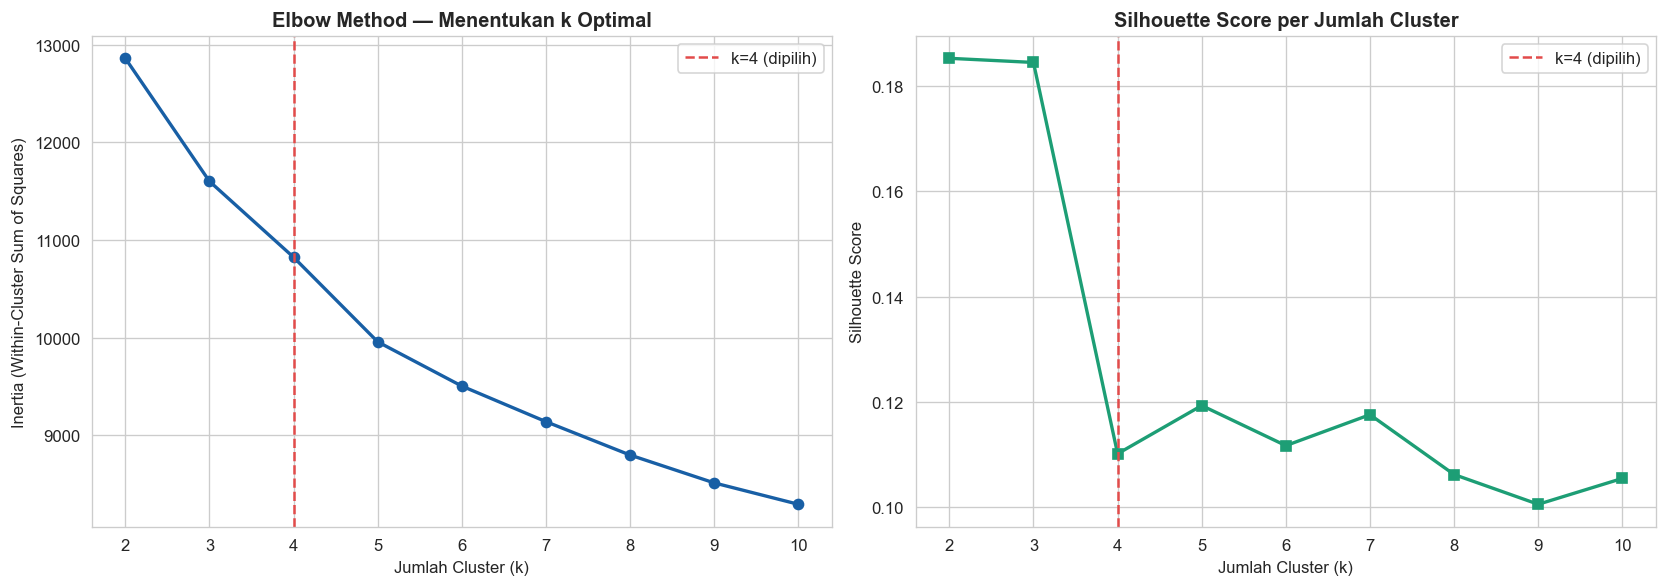


Silhouette Score per k:
  k=2: 0.1853
  k=3: 0.1845
  k=4: 0.1102 ← dipilih
  k=5: 0.1193
  k=6: 0.1117
  k=7: 0.1176
  k=8: 0.1062
  k=9: 0.1006
  k=10: 0.1055


In [ ]:
# Elbow Method
inertia_list    = []
silhouette_list = []
k_range         = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(k_range, inertia_list, 'o-', color='#185FA5', lw=2)
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method — Menentukan k Optimal', fontsize=12, fontweight='bold')
axes[0].axvline(x=4, color='#E24B4A', linestyle='--', label='k=4 (dipilih)')
axes[0].legend()

# Silhouette score
axes[1].plot(k_range, silhouette_list, 's-', color='#1D9E75', lw=2)
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per Jumlah Cluster', fontsize=12, fontweight='bold')
axes[1].axvline(x=4, color='#E24B4A', linestyle='--', label='k=4 (dipilih)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../app/assets/elbow.png', bbox_inches='tight')
plt.show()

print('\nSilhouette Score per k:')
for k, s in zip(k_range, silhouette_list):
    mark = ' ← dipilih' if k == 4 else ''
    print(f'  k={k}: {s:.4f}{mark}')

### 5.2 Training K-Means dengan k=4

In [ ]:
# Training K-Means final dengan k=4
# (ubah nilai k sesuai hasil elbow/silhouette terbaik kalian)
K_OPTIMAL = 4

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Tambahkan label cluster ke dataframe
df_encoded['Cluster'] = kmeans.labels_
df_clean['Cluster']   = kmeans.labels_

sil = silhouette_score(X_scaled, kmeans.labels_)
print(f'✅ K-Means selesai!')
print(f'   Jumlah cluster  : {K_OPTIMAL}')
print(f'   Silhouette Score: {sil:.4f}')
print(f'   Inertia         : {kmeans.inertia_:.2f}')

# Simpan model
joblib.dump(kmeans, '../model/kmeans_model.pkl')
print('✅ Model K-Means tersimpan di model/kmeans_model.pkl')

✅ K-Means selesai!
   Jumlah cluster  : 4
   Silhouette Score: 0.1102
   Inertia         : 10823.12
✅ Model K-Means tersimpan di model/kmeans_model.pkl


### 5.3 Visualisasi Cluster

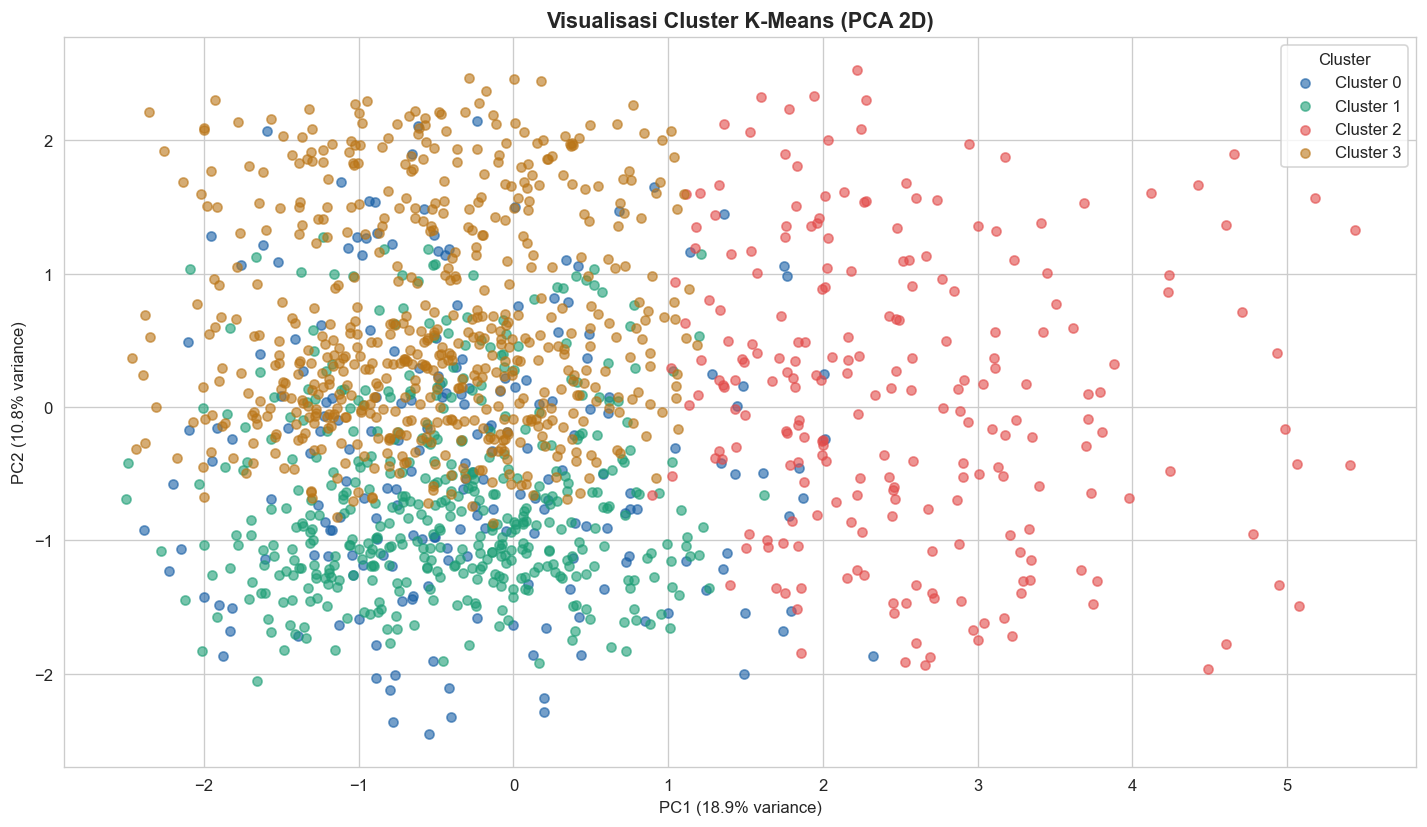

In [ ]:
# Reduksi dimensi dengan PCA untuk visualisasi 2D
pca       = PCA(n_components=2, random_state=42)
X_pca     = pca.fit_transform(X_scaled)
joblib.dump(pca, '../model/pca.pkl')

# Buat dataframe untuk plot
df_pca = pd.DataFrame({
    'PC1'     : X_pca[:, 0],
    'PC2'     : X_pca[:, 1],
    'Cluster' : kmeans.labels_.astype(str),
    'Attrition': df_clean['Attrition']
})

# Plot
colors = ['#185FA5', '#1D9E75', '#E24B4A', '#BA7517']
plt.figure(figsize=(12, 7))

for i, c in enumerate(sorted(df_pca['Cluster'].unique())):
    mask = df_pca['Cluster'] == c
    plt.scatter(df_pca[mask]['PC1'], df_pca[mask]['PC2'],
                c=colors[i], label=f'Cluster {c}',
                alpha=0.6, s=30)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Visualisasi Cluster K-Means (PCA 2D)', fontsize=13, fontweight='bold')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig('../app/assets/cluster_pca.png', bbox_inches='tight')
plt.show()

### 5.4 Analisis & Penamaan Cluster

In [57]:
print(cluster_features)
print("---")
print(df_clean[cluster_features].dtypes)

['Age', 'MonthlyIncome', 'JobSatisfaction', 'WorkLifeBalance', 'EnvironmentSatisfaction', 'YearsAtCompany', 'DistanceFromHome', 'OverTime', 'JobInvolvement', 'PerformanceRating']
---
Age                        int64
MonthlyIncome              int64
JobSatisfaction            int64
WorkLifeBalance            int64
EnvironmentSatisfaction    int64
YearsAtCompany             int64
DistanceFromHome           int64
OverTime                     str
JobInvolvement             int64
PerformanceRating          int64
dtype: object


In [63]:
numeric_features = df_clean[cluster_features].select_dtypes(include=['number']).columns.tolist()

cluster_analysis = df_clean.groupby('Cluster')[numeric_features].mean()

attrition_rate = df_clean.groupby('Cluster')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)

cluster_analysis['Attrition Rate (%)'] = attrition_rate
cluster_analysis = cluster_analysis.round(2)

print('Profil Rata-rata Setiap Cluster:')
cluster_analysis.style.background_gradient(cmap='RdYlGn_r', subset=['Attrition Rate (%)'])

Profil Rata-rata Setiap Cluster:


,Age,MonthlyIncome,JobSatisfaction,WorkLifeBalance,EnvironmentSatisfaction,YearsAtCompany,DistanceFromHome,JobInvolvement,PerformanceRating,Attrition Rate (%)
Cluster,,,,,,,,,,
0,35.990000,5472.520000,2.730000,2.770000,2.650000,6.120000,9.820000,2.690000,4.000000,17.700000
1,35.120000,5171.300000,2.680000,2.760000,1.680000,5.440000,11.170000,2.780000,3.000000,19.190000
2,47.550000,15018.760000,2.680000,2.740000,2.810000,15.190000,8.690000,2.710000,3.080000,7.520000
3,34.550000,4612.210000,2.780000,2.770000,3.500000,5.370000,7.680000,2.710000,3.000000,16.550000


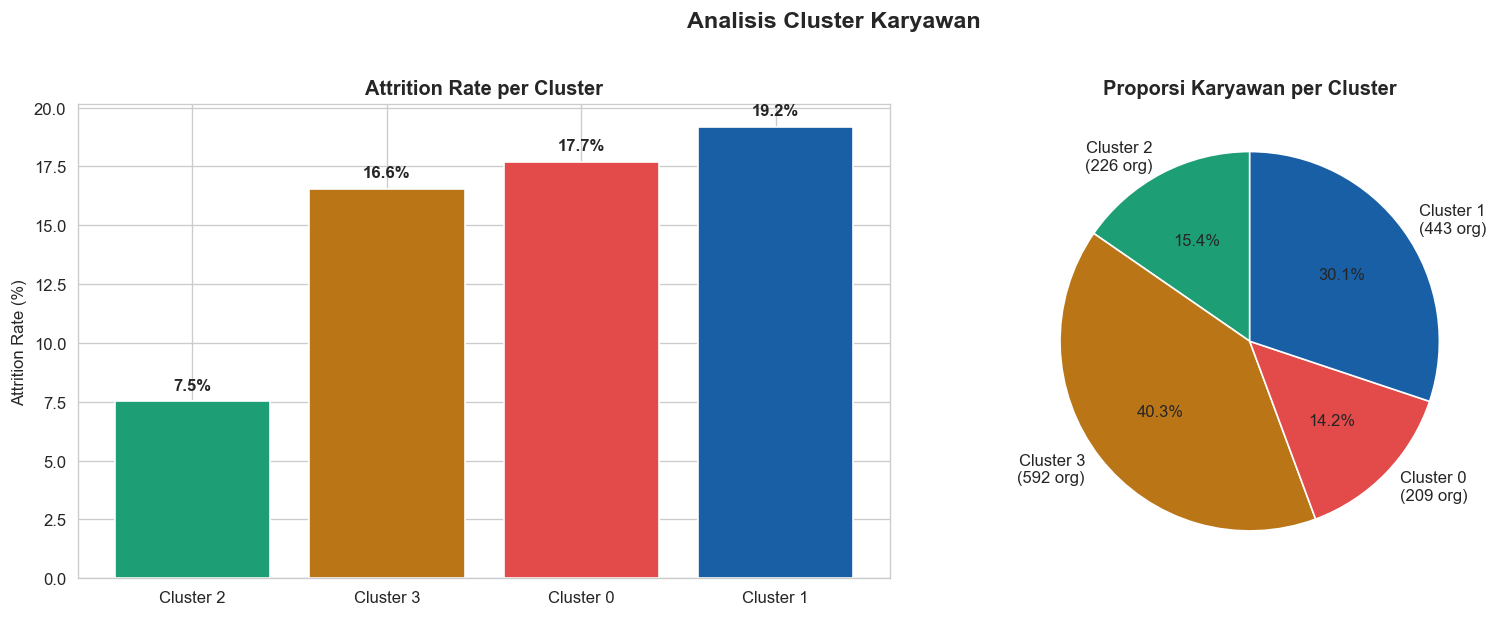

 Cluster  Attrition Rate (%)  Jumlah
       2            7.522124     226
       3           16.554054     592
       0           17.703349     209
       1           19.187359     443


In [64]:
# Attrition Rate per Cluster
cluster_attr = df_clean.groupby('Cluster')['Attrition'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
cluster_attr.columns = ['Cluster', 'Attrition Rate (%)']
cluster_attr['Jumlah'] = df_clean.groupby('Cluster').size().values

cluster_labels = {
    0: 'Karyawan Loyal & Puas',
    1: 'Karyawan Berisiko Tinggi',
    2: 'Karyawan Burnout',
    3: 'Karyawan Potensial'
}

cluster_attr = cluster_attr.sort_values('Attrition Rate (%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart attrition rate
bar_colors = ['#1D9E75', '#BA7517', '#E24B4A', '#185FA5']
bars = axes[0].bar(
    [f'Cluster {c}' for c in cluster_attr['Cluster']],
    cluster_attr['Attrition Rate (%)'],
    color=bar_colors[:len(cluster_attr)]
)
axes[0].set_title('Attrition Rate per Cluster', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
for bar, val in zip(bars, cluster_attr['Attrition Rate (%)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

# Pie chart jumlah per cluster
axes[1].pie(
    cluster_attr['Jumlah'],
    labels=[f'Cluster {c}\n({n} org)' for c, n in
            zip(cluster_attr['Cluster'], cluster_attr['Jumlah'])],
    colors=bar_colors[:len(cluster_attr)],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Proporsi Karyawan per Cluster', fontsize=12, fontweight='bold')

plt.suptitle('Analisis Cluster Karyawan', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../app/assets/cluster_analysis.png', bbox_inches='tight')
plt.show()

print(cluster_attr.to_string(index=False))

---
##  TAHAP 6 — Evaluasi & Perbandingan Model

In [65]:
# Cross-validation XGBoost
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_model, X_resampled, y_resampled,
                             cv=cv, scoring='roc_auc')

print('=' * 50)
print('  RINGKASAN EVALUASI SEMUA MODEL')
print('=' * 50)
print()
print('MODEL 1 — XGBoost Classification')
print(f'  Accuracy        : {acc:.4f} ({acc*100:.2f}%)')
print(f'  F1-Score        : {f1:.4f}')
print(f'  ROC-AUC (test)  : {roc_auc:.4f}')
print(f'  CV ROC-AUC (5x) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print()
print('MODEL 2 — K-Means Clustering')
print(f'  Jumlah Cluster  : {K_OPTIMAL}')
print(f'  Silhouette Score: {sil:.4f}')
print(f'  Inertia         : {kmeans.inertia_:.2f}')
print('=' * 50)

  RINGKASAN EVALUASI SEMUA MODEL

MODEL 1 — XGBoost Classification
  Accuracy        : 0.9231 (92.31%)
  F1-Score        : 0.9234
  ROC-AUC (test)  : 0.9738
  CV ROC-AUC (5x) : 0.9749 ± 0.0055

MODEL 2 — K-Means Clustering
  Jumlah Cluster  : 4
  Silhouette Score: 0.1102
  Inertia         : 10823.12


---
## TAHAP 7 — Cek Semua File Model Tersimpan

In [68]:
import os

model_files = [
    '../model/xgb_model.pkl',
    '../model/kmeans_model.pkl',
    '../model/scaler.pkl',
    '../model/encoders.pkl',
    '../model/feature_names.pkl',
    '../model/cluster_features.pkl',
    '../model/shap_explainer.pkl',
    '../model/pca.pkl'
]

print('Cek file model yang tersimpan:')
print('-' * 45)
all_ok = True
for f in model_files:
    exists = os.path.exists(f)
    status = '✅' if exists else '❌'
    size   = f'{os.path.getsize(f)/1024:.1f} KB' if exists else 'TIDAK ADA'
    print(f'  {status} {os.path.basename(f):<30} {size}')
    if not exists:
        all_ok = False

print('-' * 45)
if all_ok:
    print('\n Semua model siap digunakan di Streamlit!')
else:
    print('\n Ada file yang belum tersimpan, cek ulang cell di atas.')

Cek file model yang tersimpan:
---------------------------------------------
  ✅ xgb_model.pkl                  499.7 KB
  ✅ kmeans_model.pkl               6.8 KB
  ✅ scaler.pkl                     1.2 KB
  ✅ encoders.pkl                   2.4 KB
  ✅ feature_names.pkl              0.5 KB
  ✅ cluster_features.pkl           0.2 KB
  ✅ shap_explainer.pkl             1913.1 KB
  ✅ pca.pkl                        1.2 KB
---------------------------------------------

 Semua model siap digunakan di Streamlit!


---
## Kesimpulan

Tuliskan kesimpulan analisis kalian di sini:

1. **Model Klasifikasi (XGBoost):**  
   Model XGBoost berhasil memprediksi attrition karyawan dengan akurasi X% dan ROC-AUC X.XX. Fitur paling berpengaruh berdasarkan SHAP adalah OverTime, MonthlyIncome, dan YearsAtCompany.

2. **Model Clustering (K-Means):**  
   K-Means menghasilkan 4 cluster dengan Silhouette Score X.XX. Cluster yang paling berisiko resign adalah Cluster X dengan attrition rate X%.

3. **Rekomendasi Bisnis:**  
   - Prioritaskan perhatian pada karyawan di Cluster berisiko tinggi
   - Kurangi overtime dan tingkatkan kompensasi pada karyawan dengan income rendah
   - Program work-life balance untuk karyawan dengan skor rendah